In [ ]:
import torch
import torch.nn as nn

In [ ]:
# 코드 4-3 GELU 활성화 함수의 구현

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )

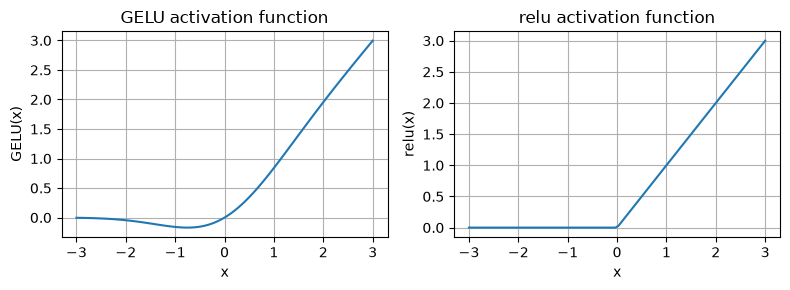

In [ ]:
# GELU 함수와 ReLU 함수를 비교해 보기 위해 두 함수를 나란히 그려 보겠다.

import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)

y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "relu"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# GPT-2 모델 설정값
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 어휘사전 크기
    "context_length": 1024, # 문맥 길이
    "emb_dim": 768,         # 임베딩 차원
    "n_heads": 12,          # 어텐션 헤드 개수
    "n_layers": 12,         # 층 개수
    "drop_rate": 0.1,       # 드롭아웃 비율
    "qkv_bias": False       # 쿼리, 키, 값 계산을 위한 편향
}

In [ ]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(num_embeddings=cfg["vocab_size"], embedding_dim=cfg["emb_dim"])
        self.pos_emb = nn.Embedding(num_embeddings=cfg["context_length"], embedding_dim=cfg["emb_dim"])
        self.drop_emb = nn.Dropout(p=cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(in_features=cfg["emb_dim"], out_features=cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len), device=in_idx.device)
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, enps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [ ]:
# 코드 4-2 층 정규화 클래스

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
# 코드 4-4 피드 포워드 신경망 모듈

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# 토큰 임베딩 크기를 768로 하여 새로운 FeedForward 모듈을 초기화
# 그런 다음 2개의 샘플과 각각 3개의 토큰을 가진 배치 입력을 전달해 보겠다.

ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2, 3, 768)

print(f"Before:\n{x}")
out = ffn(x)
print(f"After:\n{out}")
print(f"After shape: {out.shape}")

Before:
tensor([[[0.4726, 0.6198, 0.6683,  ..., 0.0757, 0.6777, 0.6322],
         [0.1790, 0.5755, 0.7812,  ..., 0.1614, 0.1187, 0.8130],
         [0.6921, 0.8421, 0.7986,  ..., 0.8195, 0.3224, 0.7029]],

        [[0.8585, 0.4741, 0.5513,  ..., 0.8395, 0.4180, 0.9555],
         [0.4670, 0.4609, 0.4387,  ..., 0.6222, 0.6090, 0.7143],
         [0.3829, 0.4949, 0.1797,  ..., 0.4257, 0.5971, 0.3317]]])
After:
tensor([[[ 0.0751,  0.0931, -0.1215,  ..., -0.1407,  0.0774,  0.0144],
         [ 0.0100,  0.0378, -0.1344,  ..., -0.2209,  0.0657, -0.0050],
         [ 0.0830,  0.1493, -0.0849,  ..., -0.2430,  0.0063,  0.0511]],

        [[-0.0034,  0.0886, -0.1224,  ..., -0.0057,  0.0715,  0.0148],
         [ 0.0943,  0.0984, -0.1111,  ..., -0.0893,  0.0754, -0.0127],
         [ 0.0825,  0.0640, -0.0923,  ..., -0.0449, -0.0504,  0.0176]]],
       grad_fn=<ViewBackward0>)
After shape: torch.Size([2, 3, 768])
